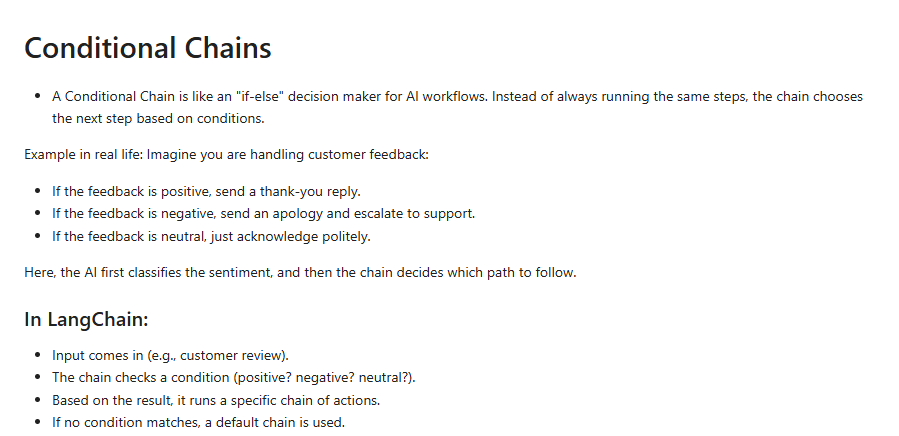

In [ ]:
!pip install langchain-google-genai

In [2]:
#importing libraries
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema.output_parser import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnableBranch
from google.colab import userdata

In [3]:
#api key
api_key = userdata.get("GOOGLE_API_KEY")

In [4]:
#selecting the model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.0-flash",
    google_api_key = api_key
)

In [5]:
#providing 4 prompt templates
positive_feedback_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human","Generate a thank you note for this positive feedback: {feedback}."),
    ]
)
negative_feedback_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human","Generate a response addressing this negative feedback: {feedback}."),
    ]
)
neutral_feedback_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human","Generate a request for more details for this neutral feedback: {feedback}."),
    ]
)
escalate_feedback_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human", "Generate a message to escalate this feedback to a human agent: {feedback}."),
    ]
)

In [6]:
#creating a prompt template for classification
classification_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("human", "Classify the sentiment of this feedback as positive, negative, neutral, or escalate: {feedback}."),
    ]
)

In [7]:
# Defining branches (different paths depending on sentiment)
# If output contains "positive", run the positive feedback chain, same for negative & neutral.
branches = RunnableBranch(
    (lambda x: "positive" in x, positive_feedback_template | llm | StrOutputParser()),
    (lambda x: "negative" in x, negative_feedback_template | llm | StrOutputParser()),
    (lambda x: "neutral" in x, neutral_feedback_template | llm | StrOutputParser()),
    # Default branch: if nothing matches, escalate the feedback
    escalate_feedback_template | llm | StrOutputParser()
)
# Main chain: takes input → classifies sentiment → returns result
classification_chain = classification_template | llm | StrOutputParser()

In [8]:
# Classifying the input first, then following the correct path (branch)
chain = classification_chain | branches

In [9]:
#providing review
review = "The product is terrible. It broke after just one use and the quality is very poor."

response = chain.invoke({
    "feedback":review
})

#getting response
print(response)

Okay, here are a few options for escalating the feedback "Negative" to a human agent, with slightly different tones:

**Option 1 (Simple and Direct):**

> Escalating to a human agent. Feedback received: "Negative."

**Option 2 (Adding Context):**

> Escalating to a human agent for review.  The customer's feedback was simply: "Negative."

**Option 3 (Slightly More Urgent):**

> Escalating to a human agent due to negative feedback. Please investigate.

**Option 4 (If you know where the feedback came from):**

> Escalating [Source of feedback - e.g., "customer support chat"] to a human agent. Feedback received: "Negative." Please investigate.

**Option 5 (If you suspect a problem):**

> Escalating to a human agent.  Received negative feedback ("Negative").  Possible issue requiring further investigation.

Choose the option that best fits your situation and the context of the feedback.  Good luck!
